# Submission 5 — Improved LightGBM (Walk-forward CV + Gini feval + Optuna)

Same features as Sub 2 (depth-0 + 4 depth-1 aggregations + stability filter).

Improvements over Sub 2:
1. **Walk-forward CV** — 3 time-based folds instead of one train/val split
2. **Custom `feval`** — early-stop on Gini stability, not AUC
3. **Optuna tuning** — 10 trials optimising Gini stability directly

Outputs `lgbm_test_preds.npy` for use in the updated ensemble (Sub 5).

In [1]:
import glob
import polars as pl
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.metrics import roc_auc_score
from scipy.stats import linregress
import matplotlib.pyplot as plt
import gc
import os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA   = '../data/raw/parquet_files'
OUTPUT = '../submissions'
TRAIN_CUTOFF = 60

## 1. Aggregate depth-1 tables

In [2]:
def aggregate_lazy(pattern: str, name: str) -> pl.DataFrame:
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No files found: {pattern}')
    print(f'{name}: {len(files)} file(s)')

    ref_schema = None
    for f in files:
        s = pl.read_parquet(f, n_rows=10).schema
        if any(v != pl.Null for v in s.values()):
            ref_schema = s
            break

    parts = []
    for f in files:
        part = pl.read_parquet(f)
        exprs = []
        for c in part.columns:
            if c == 'case_id':
                continue
            dtype = part[c].dtype
            if dtype == pl.Null and ref_schema and c in ref_schema:
                target = ref_schema[c]
                exprs.append(pl.col(c).cast(target if target != pl.Null else pl.Utf8))
            elif dtype in [pl.Float64, pl.Int64, pl.Int32, pl.Int16, pl.Int8]:
                exprs.append(pl.col(c).cast(pl.Float32))
        if exprs:
            part = part.with_columns(exprs)
        parts.append(part)

    df = pl.concat(parts, how='diagonal_relaxed')
    del parts
    gc.collect()

    schema   = df.schema
    num_cols = [c for c, dtype in schema.items() if c != 'case_id' and dtype == pl.Float32]
    cat_cols = [c for c, dtype in schema.items() if c != 'case_id' and dtype == pl.Utf8]

    aggs = [pl.len().alias(f'{name}_count').cast(pl.Int32)]
    for col in num_cols:
        aggs += [
            pl.col(col).mean().alias(f'{name}_{col}_mean'),
            pl.col(col).max().alias(f'{name}_{col}_max'),
            pl.col(col).min().alias(f'{name}_{col}_min'),
            pl.col(col).std().alias(f'{name}_{col}_std'),
        ]
    for col in cat_cols:
        aggs.append(pl.col(col).n_unique().cast(pl.Int16).alias(f'{name}_{col}_nunique'))

    result = df.group_by('case_id').agg(aggs)
    del df
    gc.collect()
    print(f'  -> {result.shape}')
    return result

In [3]:
agg_applprev      = aggregate_lazy(f'{DATA}/train/train_applprev_1_*.parquet',        'applprev')
agg_cb_a          = aggregate_lazy(f'{DATA}/train/train_credit_bureau_a_1_*.parquet', 'cb_a')
agg_cb_b          = aggregate_lazy(f'{DATA}/train/train_credit_bureau_b_1.parquet',   'cb_b')
agg_person        = aggregate_lazy(f'{DATA}/train/train_person_1.parquet',            'person')

agg_applprev_test = aggregate_lazy(f'{DATA}/test/test_applprev_1_*.parquet',          'applprev')
agg_cb_a_test     = aggregate_lazy(f'{DATA}/test/test_credit_bureau_a_1_*.parquet',   'cb_a')
agg_cb_b_test     = aggregate_lazy(f'{DATA}/test/test_credit_bureau_b_1.parquet',     'cb_b')
agg_person_test   = aggregate_lazy(f'{DATA}/test/test_person_1.parquet',              'person')

applprev: 2 file(s)
  -> (1221522, 97)
cb_a: 4 file(s)
  -> (1386273, 245)
cb_b: 1 file(s)
  -> (36500, 139)
person: 1 file(s)
  -> (1526659, 51)
applprev: 3 file(s)
  -> (4, 98)
cb_a: 5 file(s)
  -> (5, 245)
cb_b: 1 file(s)
  -> (3, 139)
person: 1 file(s)
  -> (6, 51)


## 2. Load depth-0 tables and join

In [4]:
def cast_static(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.col(c).cast(pl.Float32)
        for c in df.columns
        if df[c].dtype in [pl.Float64, pl.Int64, pl.Int32]
        and c not in ('case_id', 'target', 'WEEK_NUM', 'MONTH')
    ])

base      = pl.read_parquet(f'{DATA}/train/train_base.parquet')
static0   = pl.scan_parquet(sorted(glob.glob(f'{DATA}/train/train_static_0_*.parquet'))).collect().pipe(cast_static)
static_cb = pl.read_parquet(f'{DATA}/train/train_static_cb_0.parquet').pipe(cast_static)

test_base      = pl.read_parquet(f'{DATA}/test/test_base.parquet')
test_static0   = pl.scan_parquet(sorted(glob.glob(f'{DATA}/test/test_static_0_*.parquet'))).collect().pipe(cast_static)
test_static_cb = pl.read_parquet(f'{DATA}/test/test_static_cb_0.parquet').pipe(cast_static)

def build(base_df, s0, scb, aggs):
    df = base_df.join(s0, on='case_id', how='left').join(scb, on='case_id', how='left')
    for agg in aggs:
        df = df.join(agg, on='case_id', how='left')
    return df

df   = build(base, static0, static_cb, [agg_applprev, agg_cb_a, agg_cb_b, agg_person])
test = build(test_base, test_static0, test_static_cb, [agg_applprev_test, agg_cb_a_test, agg_cb_b_test, agg_person_test])

del static0, static_cb, test_static0, test_static_cb
del agg_applprev, agg_cb_a, agg_cb_b, agg_person
del agg_applprev_test, agg_cb_a_test, agg_cb_b_test, agg_person_test
gc.collect()

print(f'Train: {df.shape}')
print(f'Test:  {test.shape}')

Train: (1526659, 752)
Test:  (10, 752)


## 3. Preprocessing

In [5]:
DROP_COLS = ['case_id', 'date_decision', 'MONTH', 'WEEK_NUM', 'target']
TEST_DROP = ['case_id', 'date_decision', 'MONTH', 'WEEK_NUM']

def preprocess(df: pl.DataFrame, drop_cols: list) -> pl.DataFrame:
    date_cols = [c for c in df.columns if c.endswith('_D') and c not in drop_cols]
    for col in date_cols:
        df = df.with_columns(
            pl.col(col).str.to_date(strict=False).cast(pl.Int32).alias(col)
        )
    cat_cols = [c for c in df.columns if df[c].dtype == pl.Utf8 and c not in drop_cols]
    for col in cat_cols:
        df = df.with_columns(
            pl.col(col).cast(pl.Categorical).to_physical().cast(pl.Int16).alias(col)
        )
    return df.drop([c for c in drop_cols if c in df.columns])

week_num = df['WEEK_NUM'].to_numpy()
y        = df['target'].to_numpy()

X_df      = preprocess(df, DROP_COLS)
X_test_df = preprocess(test, TEST_DROP)
del df, test
gc.collect()

feature_cols = [c for c in X_df.columns if c in X_test_df.columns]
X_df         = X_df.select(feature_cols)
X_test_df    = X_test_df.select(feature_cols)

print(f'Features before stability filter: {len(feature_cols)}')

Features before stability filter: 747


## 4. Stability-first feature filtering

In [6]:
train_mask = week_num <= TRAIN_CUTOFF

numeric_cols = [
    c for c in X_df.columns
    if X_df[c].dtype in [pl.Float32, pl.Float64, pl.Int32, pl.Int16, pl.Int8]
]

df_wk = X_df.filter(pl.Series(train_mask)).select(numeric_cols).with_columns(
    pl.Series('WEEK_NUM', week_num[train_mask])
)
weekly_means = df_wk.group_by('WEEK_NUM').agg([pl.col(c).mean() for c in numeric_cols]).sort('WEEK_NUM')

drift = {}
for col in numeric_cols:
    vals = weekly_means[col].drop_nulls().to_numpy()
    if len(vals) < 5 or np.abs(vals.mean()) < 1e-9:
        drift[col] = 0.0
    else:
        drift[col] = vals.std() / np.abs(vals.mean())

del df_wk, weekly_means
gc.collect()

drift_df   = pl.DataFrame({'feature': list(drift.keys()), 'drift': list(drift.values())}).sort('drift', descending=True)
n_drop     = max(1, int(len(drift_df) * 0.10))
unstable   = set(drift_df.head(n_drop)['feature'].to_list())
stable_features = [c for c in feature_cols if c not in unstable]

print(f'Dropped {len(unstable)} unstable features, {len(stable_features)} remaining')

Dropped 74 unstable features, 673 remaining


In [7]:
X      = X_df.select(stable_features).to_numpy()
X_test = X_test_df.select(stable_features).to_numpy()
del X_df, X_test_df
gc.collect()
print(f'Feature matrix: {X.shape}, Test: {X_test.shape}')

scale_pos = float((y == 0).sum() / (y == 1).sum())


Feature matrix: (1526659, 673), Test: (10, 673)


## 5. Gini stability metric

In [8]:
def gini_stability(week_nums, targets, preds):
    weeks = np.unique(week_nums)
    weekly_gini = []
    for w in weeks:
        mask = week_nums == w
        if targets[mask].sum() == 0:
            continue
        weekly_gini.append(2 * roc_auc_score(targets[mask], preds[mask]) - 1)
    weekly_gini = np.array(weekly_gini)
    mean_gini   = weekly_gini.mean()
    slope, intercept, *_ = linregress(np.arange(len(weekly_gini)), weekly_gini)
    residuals   = weekly_gini - (intercept + slope * np.arange(len(weekly_gini)))
    return mean_gini + 88.0 * min(0, slope) - 0.5 * residuals.std(), mean_gini, slope, residuals.std(), weekly_gini

## 6. Walk-forward CV helpers

Three expanding-window folds — each fold trains on all weeks up to `train_end`,
validates on the immediately following window. This gives a more honest stability
estimate than a single split and is required for Optuna to tune on.

In [9]:
FOLDS = [
    (0, 40,  41, 60),   # fold 1: train 0-40, val 41-60
    (0, 60,  61, 75),   # fold 2: train 0-60, val 61-75
    (0, 75,  76, 91),   # fold 3: train 0-75, val 76-91
]

# Module-level variable used by the custom feval closure (set before each fold's fit call).
current_val_weeks = None

def gini_stability_feval(y_true, y_pred):
    """LightGBM custom eval metric. Signature: (y_true, y_pred) -> (name, value, higher_is_better)"""
    score, *_ = gini_stability(current_val_weeks, y_true, y_pred)
    return 'gini_stability', score, True

def run_cv(params, verbose=True):
    """Walk-forward CV. Returns mean Gini stability across folds."""
    global current_val_weeks
    scores = []
    for i, (tr_start, tr_end, va_start, va_end) in enumerate(FOLDS):
        tr_mask = (week_num >= tr_start) & (week_num <= tr_end)
        va_mask = (week_num >= va_start) & (week_num <= va_end)

        X_tr, y_tr = X[tr_mask], y[tr_mask]
        X_va, y_va = X[va_mask], y[va_mask]
        current_val_weeks = week_num[va_mask]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric=gini_stability_feval,
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(0),
            ],
        )

        preds = model.predict_proba(X_va)[:, 1]
        score, mean_g, slope, resid_std, _ = gini_stability(current_val_weeks, y_va, preds)
        scores.append(score)
        if verbose:
            print(f'  Fold {i+1} | best_iter={model.best_iteration_:4d} | '
                  f'gini_stab={score:.4f}  (mean_gini={mean_g:.4f}, slope={slope:.5f}, resid_std={resid_std:.4f})')

    mean_score = float(np.mean(scores))
    if verbose:
        print(f'Mean Gini stability across folds: {mean_score:.4f}')
    return mean_score

### Sanity check: baseline params through walk-forward CV

In [10]:
baseline_params = {
    'objective': 'binary', 'metric': 'custom',
    'n_estimators': 1000, 'learning_rate': 0.05,
    'num_leaves': 63, 'min_child_samples': 50,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1,
    'reg_alpha': 0.1, 'reg_lambda': 0.1,
    'scale_pos_weight': (y == 0).sum() / (y == 1).sum(),
    'n_jobs': -1, 'verbose': -1, 'random_state': 42,
}

print('Baseline walk-forward CV:')
baseline_score = run_cv(baseline_params)

Baseline walk-forward CV:
  Fold 1 | best_iter= 148 | gini_stab=0.5774  (mean_gini=0.6409, slope=-0.00060, resid_std=0.0207)
  Fold 2 | best_iter= 231 | gini_stab=0.6422  (mean_gini=0.6652, slope=0.00411, resid_std=0.0460)
  Fold 3 | best_iter= 425 | gini_stab=0.7007  (mean_gini=0.7157, slope=0.00240, resid_std=0.0299)
Mean Gini stability across folds: 0.6401


## 7. Optuna hyperparameter search

10 trials, each running 3-fold walk-forward CV.
After it finishes, copy `study.best_params` into the cell below and re-run the final training block.

In [11]:
def objective(trial):
    params = {
        'objective': 'binary', 'metric': 'custom',
        'n_estimators': 1000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      1,
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 1.0),
        'scale_pos_weight':  scale_pos,
        'n_jobs': -1, 'verbose': -1, 'random_state': 42,
    }
    return run_cv(params, verbose=False)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

print('\nBest Gini stability:', study.best_value)
print('Best params:', study.best_params)

  0%|          | 0/10 [00:00<?, ?it/s]


Best Gini stability: 0.6540572530678102
Best params: {'learning_rate': 0.022812809566861304, 'num_leaves': 55, 'min_child_samples': 38, 'feature_fraction': 0.774816395214887, 'bagging_fraction': 0.5187196516747448, 'reg_alpha': 0.7931156231178, 'reg_lambda': 0.3782056934716548}


## 8. Final training with best params

Paste Optuna's `best_params` into `tuned_params` below after the search finishes.
The defaults here are reasonable placeholders until then.

In [12]:
# Replace with study.best_params after Optuna finishes
tuned_params = {
    'objective': 'binary', 'metric': 'custom',
    'n_estimators': 1000,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 50,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      1,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'scale_pos_weight':  scale_pos,
    'n_jobs': -1, 'verbose': -1, 'random_state': 42,
}

print('Tuned params walk-forward CV:')
tuned_score = run_cv(tuned_params)
print(f'\nImprovement over baseline: {tuned_score - baseline_score:+.4f}')

Tuned params walk-forward CV:
  Fold 1 | best_iter= 148 | gini_stab=0.5774  (mean_gini=0.6409, slope=-0.00060, resid_std=0.0207)
  Fold 2 | best_iter= 231 | gini_stab=0.6422  (mean_gini=0.6652, slope=0.00411, resid_std=0.0460)
  Fold 3 | best_iter= 425 | gini_stab=0.7007  (mean_gini=0.7157, slope=0.00240, resid_std=0.0299)
Mean Gini stability across folds: 0.6401

Improvement over baseline: +0.0000


## 9. Evaluate on last fold (val weeks 76–91)

[100]	valid_0's gini_stability: 0.679779
[200]	valid_0's gini_stability: 0.695176
[300]	valid_0's gini_stability: 0.698868
[400]	valid_0's gini_stability: 0.70032
Validation AUC:        0.8603
Gini stability score:  0.7007
  Mean weekly Gini:    0.7157
  Trend slope:         0.002398
  Residual std:        0.0299


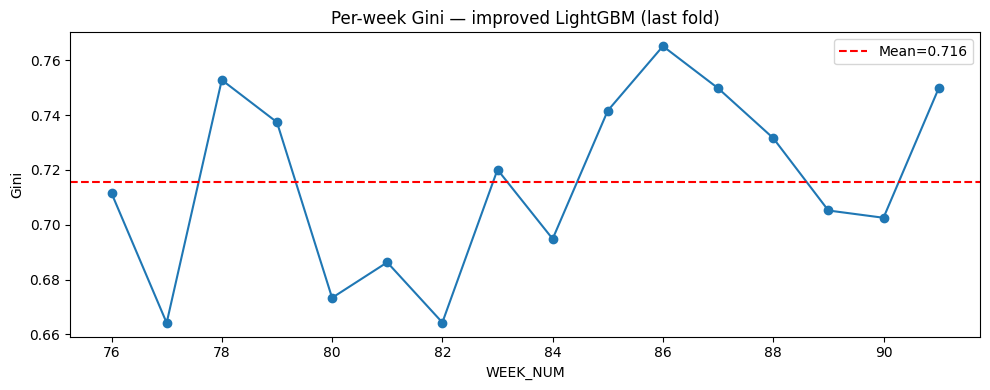

In [13]:
tr_mask = week_num <= 75
va_mask = week_num > 75

X_tr, y_tr = X[tr_mask], y[tr_mask]
X_va, y_va = X[va_mask], y[va_mask]
current_val_weeks = week_num[va_mask]

eval_model = lgb.LGBMClassifier(**tuned_params)
eval_model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    eval_metric=gini_stability_feval,
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

val_preds = eval_model.predict_proba(X_va)[:, 1]
auc = roc_auc_score(y_va, val_preds)
score, mean_gini, slope, resid_std, weekly_gini = gini_stability(current_val_weeks, y_va, val_preds)

print(f'Validation AUC:        {auc:.4f}')
print(f'Gini stability score:  {score:.4f}')
print(f'  Mean weekly Gini:    {mean_gini:.4f}')
print(f'  Trend slope:         {slope:.6f}')
print(f'  Residual std:        {resid_std:.4f}')

valid_weeks = [w for w in np.unique(current_val_weeks) if y_va[current_val_weeks == w].sum() > 0]
plt.figure(figsize=(10, 4))
plt.plot(valid_weeks, weekly_gini, marker='o', linewidth=1.5)
plt.axhline(mean_gini, color='red', linestyle='--', label=f'Mean={mean_gini:.3f}')
plt.xlabel('WEEK_NUM'); plt.ylabel('Gini')
plt.title('Per-week Gini — improved LightGBM (last fold)')
plt.legend(); plt.tight_layout(); plt.show()

## 10. Feature importance

shape: (20, 2)
┌─────────────────────────────────┬────────────┐
│ feature                         ┆ importance │
│ ---                             ┆ ---        │
│ str                             ┆ i32        │
╞═════════════════════════════════╪════════════╡
│ price_1097A                     ┆ 407        │
│ annuity_780A                    ┆ 367        │
│ pmtnum_254L                     ┆ 284        │
│ pmtssum_45A                     ┆ 272        │
│ responsedate_4527233D           ┆ 268        │
│ …                               ┆ …          │
│ cb_a_totalamount_6A_min         ┆ 171        │
│ inittransactionamount_650A      ┆ 161        │
│ applprev_mainoccupationinc_437… ┆ 153        │
│ birthdate_574D                  ┆ 151        │
│ amtinstpaidbefduel24m_4187115A  ┆ 148        │
└─────────────────────────────────┴────────────┘


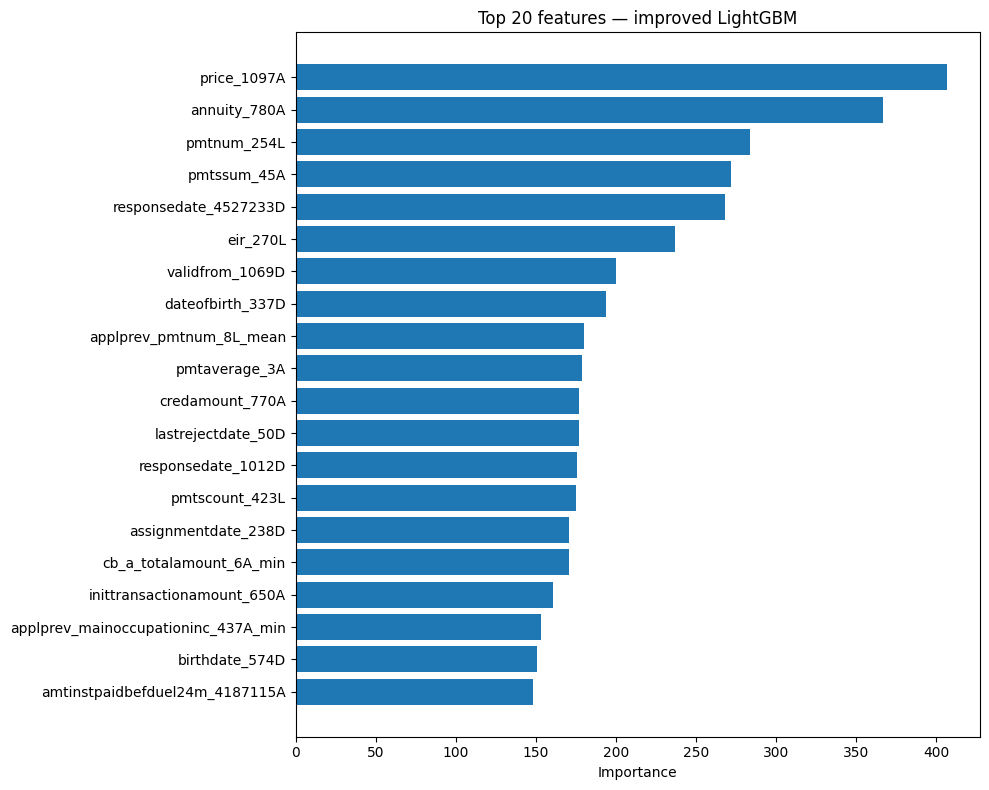

In [14]:
importance = pl.DataFrame({
    'feature':    stable_features,
    'importance': eval_model.feature_importances_
}).sort('importance', descending=True)
print(importance.head(20))

top20 = importance.head(20)
plt.figure(figsize=(10, 8))
plt.barh(top20['feature'].to_list()[::-1], top20['importance'].to_list()[::-1])
plt.xlabel('Importance'); plt.title('Top 20 features — improved LightGBM')
plt.tight_layout(); plt.show()

## 11. Retrain on full data & save predictions

In [15]:
best_n_estimators = eval_model.best_iteration_
final_params = {**tuned_params, 'n_estimators': best_n_estimators}

final_model = lgb.LGBMClassifier(**final_params)
final_model.fit(X, y)

test_preds = final_model.predict_proba(X_test)[:, 1]

# Save raw probabilities for the ensemble (05_ensemble_kaggle.ipynb)
os.makedirs(OUTPUT, exist_ok=True)
np.save(f'{OUTPUT}/lgbm_test_preds.npy', test_preds)
print(f'Saved lgbm_test_preds.npy — shape: {test_preds.shape}')

# Standalone submission (Sub 5 solo, optional)
submission = pl.DataFrame({
    'case_id': test_base['case_id'],
    'score':   test_preds
})
submission.write_csv(f'{OUTPUT}/submission_05_lgbm_improved.csv')
print(f'Saved submission_05_lgbm_improved.csv')
print(submission.describe())

Saved lgbm_test_preds.npy — shape: (10,)
Saved submission_05_lgbm_improved.csv
shape: (9, 3)
┌────────────┬───────────┬──────────┐
│ statistic  ┆ case_id   ┆ score    │
│ ---        ┆ ---       ┆ ---      │
│ str        ┆ f64       ┆ f64      │
╞════════════╪═══════════╪══════════╡
│ count      ┆ 10.0      ┆ 10.0     │
│ null_count ┆ 0.0       ┆ 0.0      │
│ mean       ┆ 57592.4   ┆ 0.275484 │
│ std        ┆ 42.253731 ┆ 0.206421 │
│ min        ┆ 57543.0   ┆ 0.030431 │
│ 25%        ┆ 57551.0   ┆ 0.07368  │
│ 50%        ┆ 57630.0   ┆ 0.270968 │
│ 75%        ┆ 57632.0   ┆ 0.474555 │
│ max        ┆ 57634.0   ┆ 0.6056   │
└────────────┴───────────┴──────────┘
